In [1]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [7]:
# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
#os.chdir(os.path.abspath('..'))
#print(os.getcwd())

df = pd.read_csv(r'C:\Users\chanhyeok\Desktop\lucky7\airbnb_price_prediction\data\df_cleaned.csv')
df.head()

,id,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,log_price,log_estimated_revenue_l365d
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,False,Prospect Heights,1.0,3.0,True,True,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200.0,90,365,90.0,90.0,365.0,365.0,90.0,365.0,True,27,57,87,362,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,False,1,0,1,0,0.05,1,1,1,5.303305,0.000000
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,1.00,False,East Harlem,1.0,1.0,True,True,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82.0,30,999,30.0,30.0,999.0,999.0,30.0,999.0,True,0,0,0,204,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,False,1,0,1,0,0.58,1,1,0,4.418841,0.000000
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,1.0,0.40,False,Boerum Hill,1.0,3.0,True,True,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765.0,3,60,3.0,3.0,60.0,60.0,3.0,60.0,True,30,49,66,326,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,False,1,0,1,0,0.28,1,1,1,6.641182,0.000000
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,1.0,0.97,True,Harlem,1.0,1.0,True,True,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139.0,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,True,7,18,25,25,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,False,1,1,0,0,1.36,1,1,0,4.941642,10.475

In [ ]:
# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
#os.chdir(os.path.abspath('..'))
#print(os.getcwd())
#
#df = pd.read_csv('data/2025_Airbnb_NYC_listings.csv').drop(columns = 'Unnamed: 0')
#df.head()

c:\Users\chanhyeok\Desktop\lucky7\airbnb_price_prediction


,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,f,Prospect Heights,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",$200.00,90,365,90.0,90.0,365.0,365.0,90.0,365.0,NaN,t,27,57,87,362,2025-03-03,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,100%,f,East Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",$82.00,30,999,30.0,30.0,999.0,999.0,30.0,999.0,NaN,t,0,0,0,204,2025-03-03,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,100%,40%,f,Boerum Hill,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",$765.00,3,60,3.0,3.0,60.0,60.0,3.0,60.0,NaN,t,30,49,66,326,2025-03-02,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,100%,97%,t,Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",$139.00,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,7,18,25,25,2025-03-03,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,

In [17]:
df['review_scores_value'].describe()

count    15510.000000
mean         4.613484
std          0.504365
min          1.000000
25%          4.510000
50%          4.750000
75%          4.890000
max          5.000000
Name: review_scores_value, dtype: float64

In [19]:
df['calculated_host_listings_count'].describe()

count    22308.000000
mean        89.472790
std        263.516627
min          1.000000
25%          1.000000
50%          3.000000
75%         19.000000
max       1194.000000
Name: calculated_host_listings_count, dtype: float64

In [ ]:
# 호스트 응답 시간 별 가격, 전체 리뷰 점수, 커뮤니케이션 리뷰 점수 평균
# nan을 포함해서 진행해봄


df_response_nan_cleaned = df.copy()
df_response_nan_cleaned['host_response_time'] = df_response_nan_cleaned['host_response_time'].fillna('NaN')

host_response_price_df = df_response_nan_cleaned.groupby('host_response_time').agg(
    mean_price=('price','mean'),
    mean_review_score=('review_scores_rating','mean'),
    mean_communication_score=('review_scores_communication','mean')
)
host_response_price_df.round(2)

,mean_price,mean_review_score,mean_communication_score
host_response_time,,,
NaN,226.77,4.74,4.85
a few days or more,163.12,4.58,4.59
within a day,171.09,4.75,4.82
within a few hours,177.64,4.76,4.84
within an hour,230.63,4.71,4.81


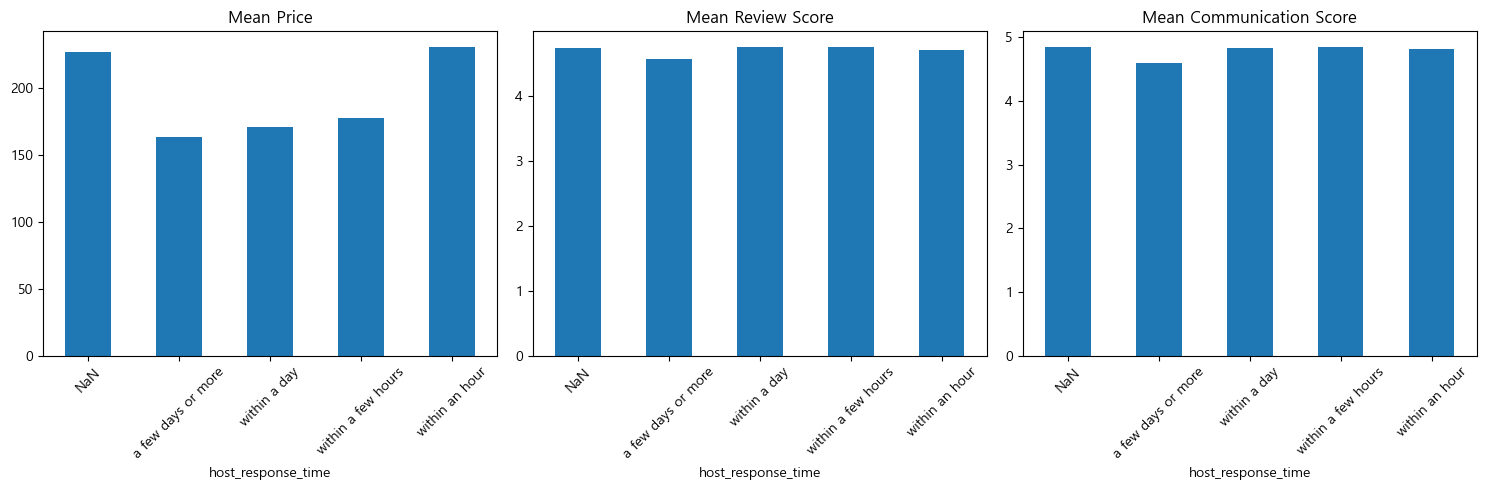

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))

host_response_price_df['mean_price'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Mean Price')
axes[0].tick_params(axis='x', rotation=45)

host_response_price_df['mean_review_score'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Mean Review Score')
axes[1].tick_params(axis='x', rotation=45)

host_response_price_df['mean_communication_score'].plot(kind='bar', ax=axes[2])
axes[2].set_title('Mean Communication Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [25]:
df['price']

0        200.0
1         82.0
2        765.0
3        139.0
4        130.0
         ...  
22303     72.0
22304     58.0
22305    299.0
22306    200.0
22307     58.0
Name: price, Length: 22308, dtype: float64